In [28]:
%load_ext autoreload
%autoreload 2

import os
import socket
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files
from msi.utils import plotting, input_output

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
hostname = socket.gethostname()
if any(x in hostname for x in ["clariden", "nid", "daint"]):
    scratch_path = "/iopsstor/scratch/cscs/athomsen"
    repo_path    = "/users/athomsen/dlss/repos"
else:
    scratch_path = "/Users/arne/data"
    repo_path    = "/Users/arne/git"

In [30]:
subversion = "rot_in_place"
msfm_conf = files.load_config(f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/{subversion}.yaml")

params_by_probe = {
    "lensing":    ["Om", "s8", "w0", "Aia", "n_Aia", "bta"],
    "clustering": ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"],
    "combined":   ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
    "2x2pt":      ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
    "cross":      ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
}

In [31]:
# run_maps = {
#     "data_type": "maps", 
#     "probe": "lensing", 
#     "model_name": "v8_cls",
#     "n_steps": 300_000
# }
# run_cls  = {
#     "data_type": "cls",  
#     "probe": "lensing", 
#     "model_name": 
#     "v33", 
#     "n_steps": 1_000_000
# }


In [32]:
# run_maps = {
#     "data_type": "maps", 
#     "probe": "clustering", 
#     "model_name": "v8_cls",
#     "n_steps": 600_000
# }
# run_cls  = {
#     "data_type": "cls",  
#     "probe": "clustering", 
#     "model_name": 
#     "v33", 
#     "n_steps": 1_000_000
# }


In [33]:
run_maps = {
    "data_type": "maps", 
    "probe": "combined", 
    "model_name": "v8_cls",
    "n_steps": 250_000
}
run_cls  = {
    "data_type": "cls",  
    "probe": "combined", 
    "model_name": 
    "v33", 
    "n_steps": 1_000_000
}


In [34]:
assert run_maps["probe"] == run_cls["probe"], "both runs must use the same probe"
probe  = run_maps["probe"]
params = params_by_probe[probe]

def get_flow_dir(run):
    return os.path.join(
        scratch_path, "deep_lss/runs/v16", subversion,
        run["data_type"], run["probe"], run["model_name"],
        f"ensemble_flow_{run['n_steps']}",
    )

flow_dir_maps = get_flow_dir(run_maps)
flow_dir_cls  = get_flow_dir(run_cls)
pred_dir_maps = os.path.dirname(flow_dir_maps)

In [35]:
_, _, _, obs_cosmo_dict = input_output.load_network_preds_simple(
    os.path.join(pred_dir_maps, f"preds_{run_maps['n_steps']}.h5")
)

26-06-23 11:22:36 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/combined/v8_cls/preds_250000.h5 
26-06-23 11:22:36 input_output INF   grid_preds.shape = (200000, 10) 
26-06-23 11:22:36 input_output INF   grid_cosmos.shape = (200000, 10) 
26-06-23 11:22:36 input_output INF   DESy3 with shape (10,) 
26-06-23 11:22:36 input_output INF   DESy3_no_psi_rot with shape (10,) 
26-06-23 11:22:36 input_output INF   DESy3_no_sys with shape (10,) 
26-06-23 11:22:36 input_output INF   DESy3_no_sys_no_psi_rot with shape (10,) 
26-06-23 11:22:36 input_output INF   box_size_mean with shape (10,) 
26-06-23 11:22:36 input_output INF   box_size_stack with shape (80, 10) 
26-06-23 11:22:36 input_output INF   fiducial_bench_dmo_mean with shape (10,) 
26-06-23 11:22:36 input_output INF   fiducial_bench_dmo_stack with shape (80, 10) 
26-06-23 11:22:36 input_output INF   fiducial_bench_mean with shape (10,) 
26-06-23 11:22:36 input_output INF   

obs_label fiducial_bench_mean not found in obs_cosmo_dict, skipping...
26-06-23 11:22:47     prior.py INF   Generated 3841699 randoms in prior 
26-06-23 11:22:49  plotting.py WAR   Not saving the plot 


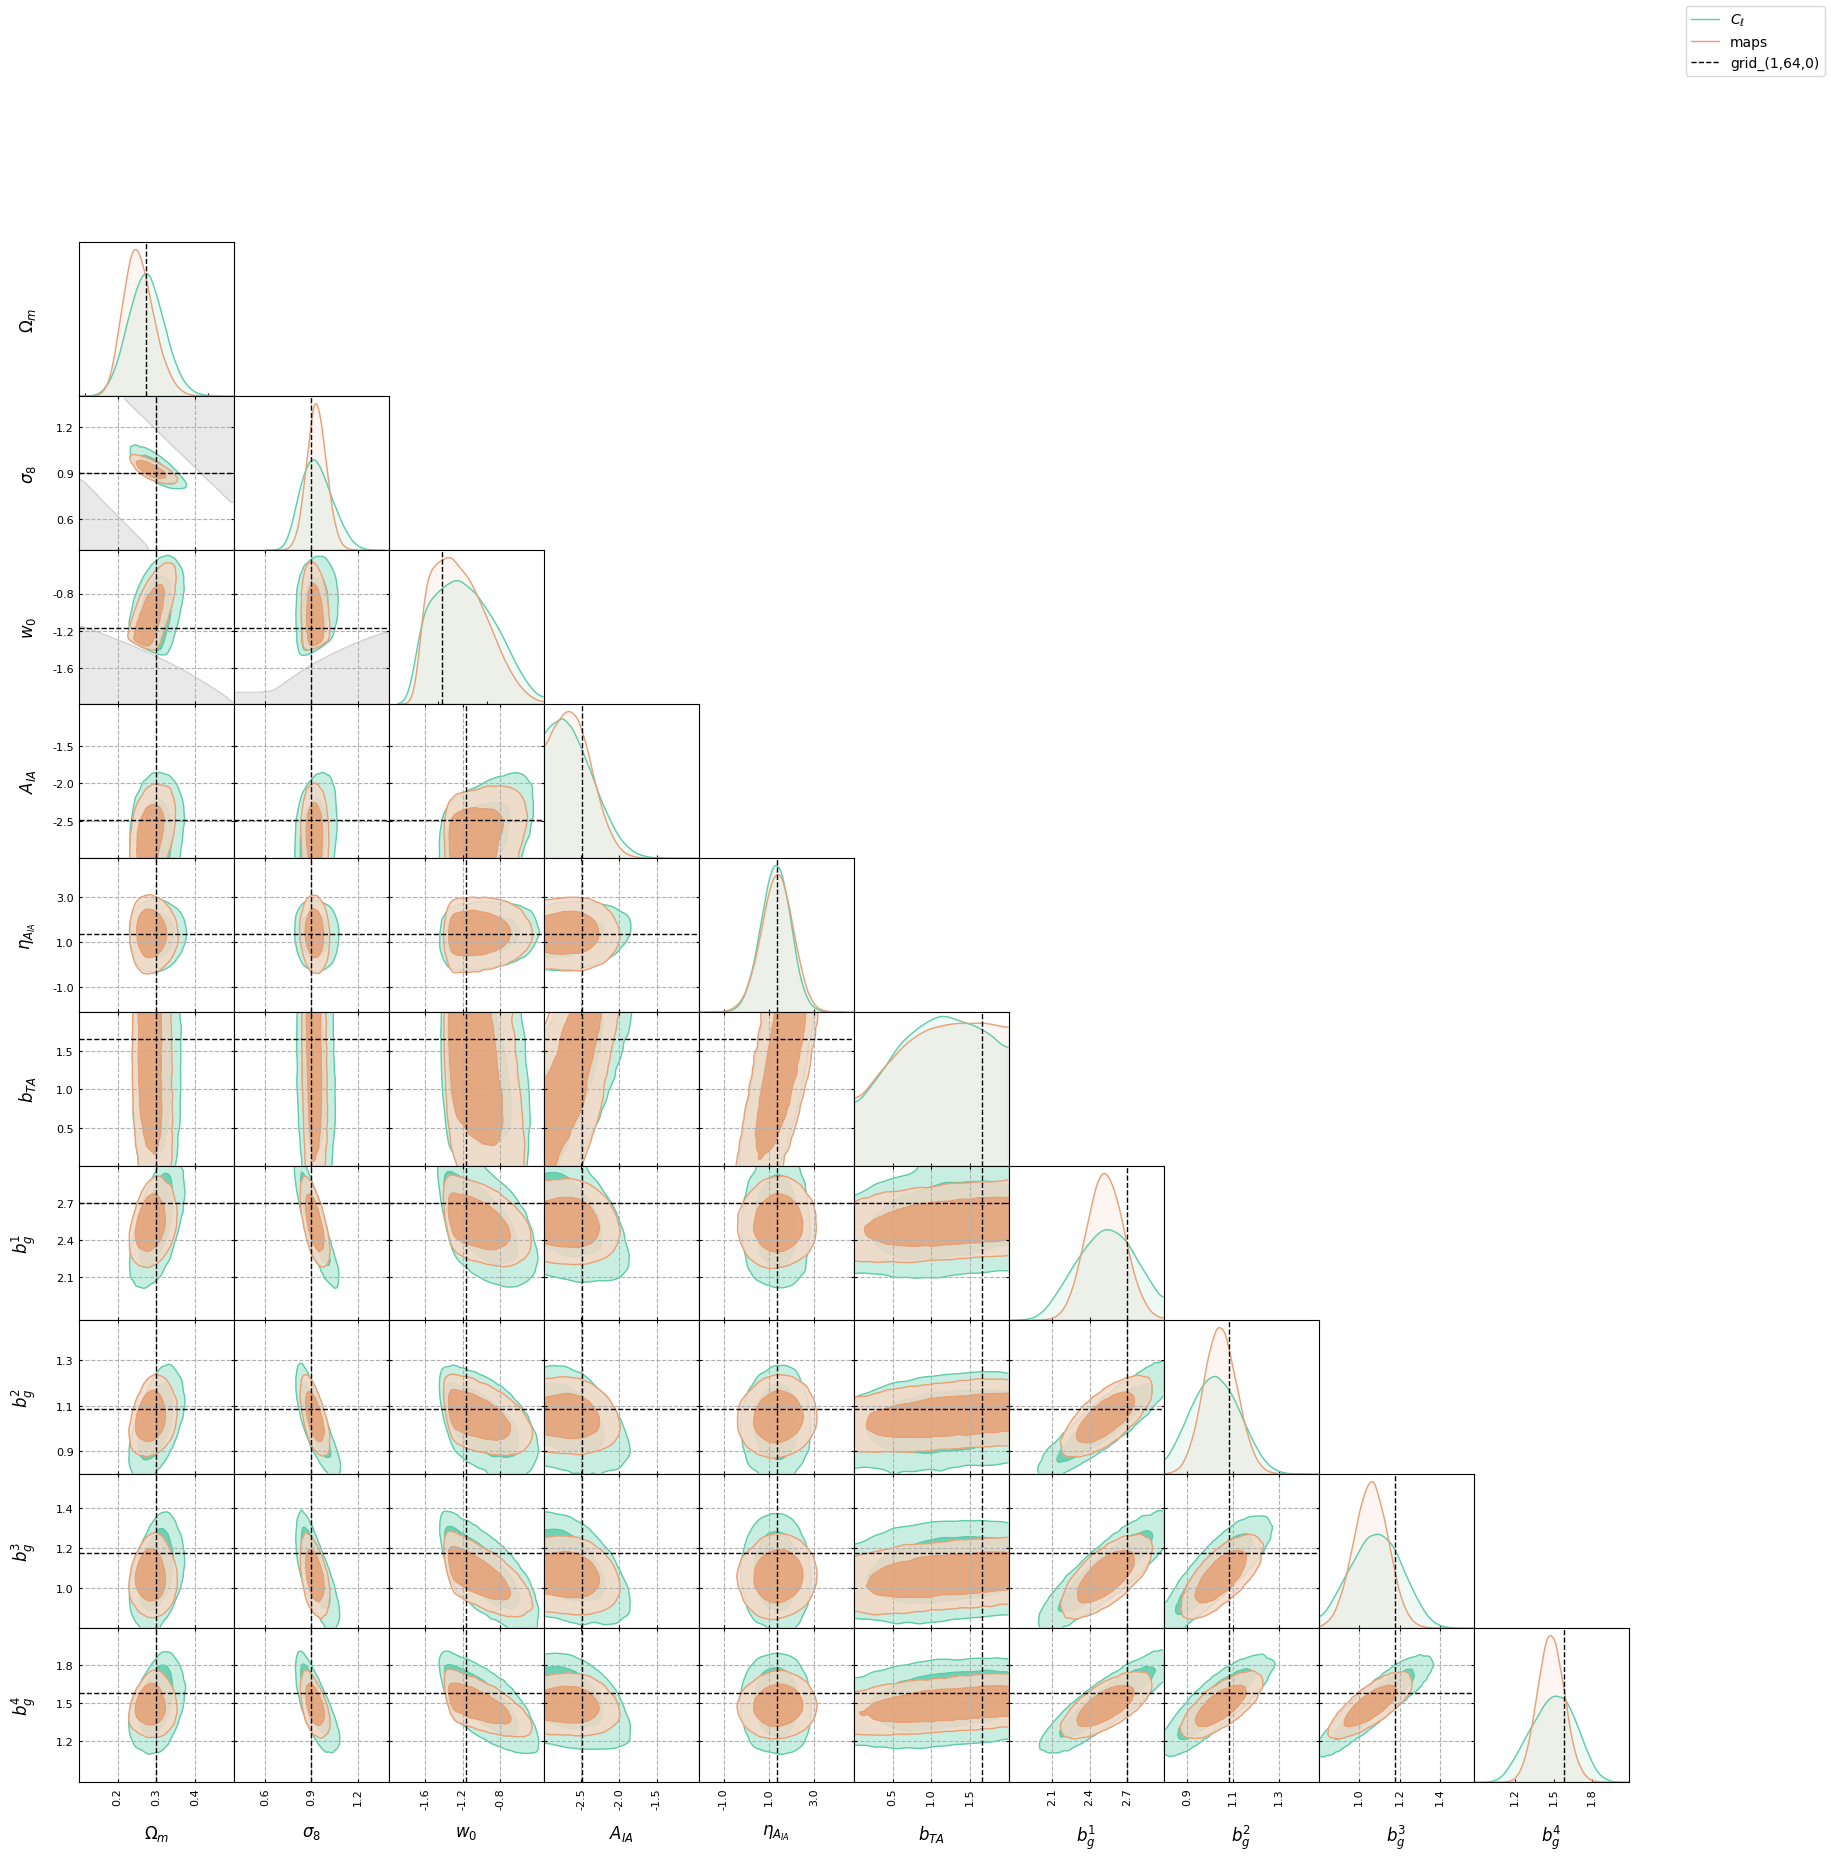

26-06-23 11:23:01     prior.py INF   Generated 3841699 randoms in prior 
26-06-23 11:23:02  plotting.py WAR   Not saving the plot 


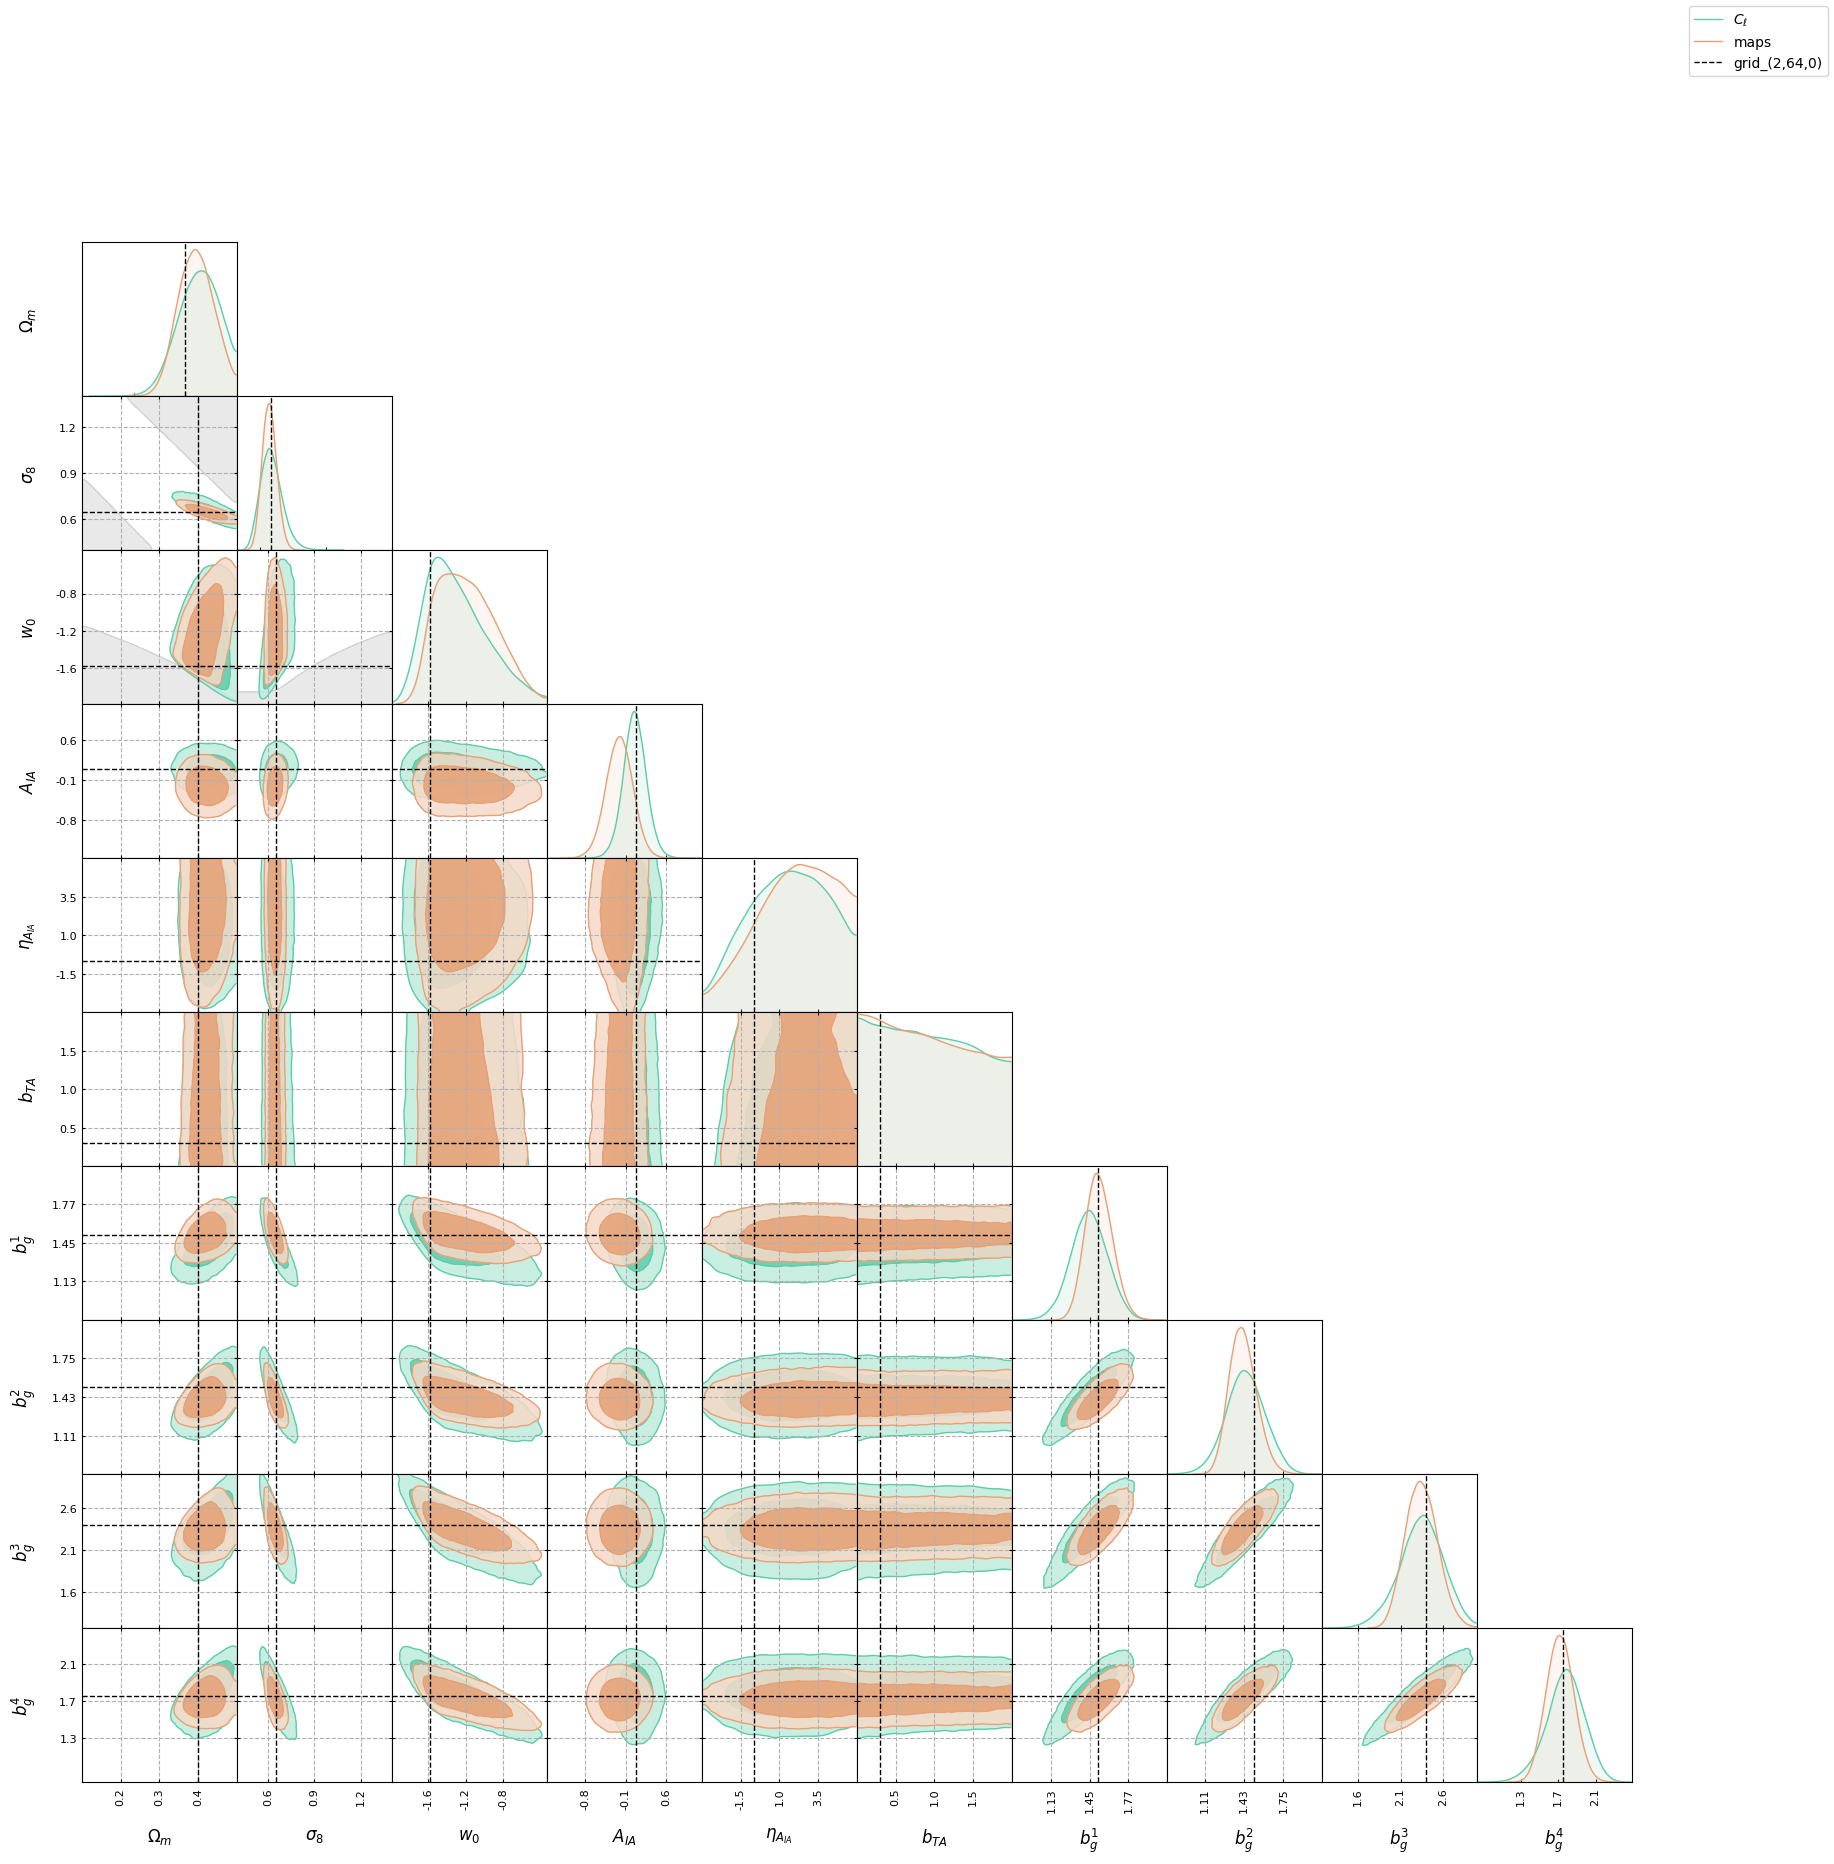

26-06-23 11:23:14     prior.py INF   Generated 3841699 randoms in prior 
26-06-23 11:23:15  plotting.py WAR   Not saving the plot 


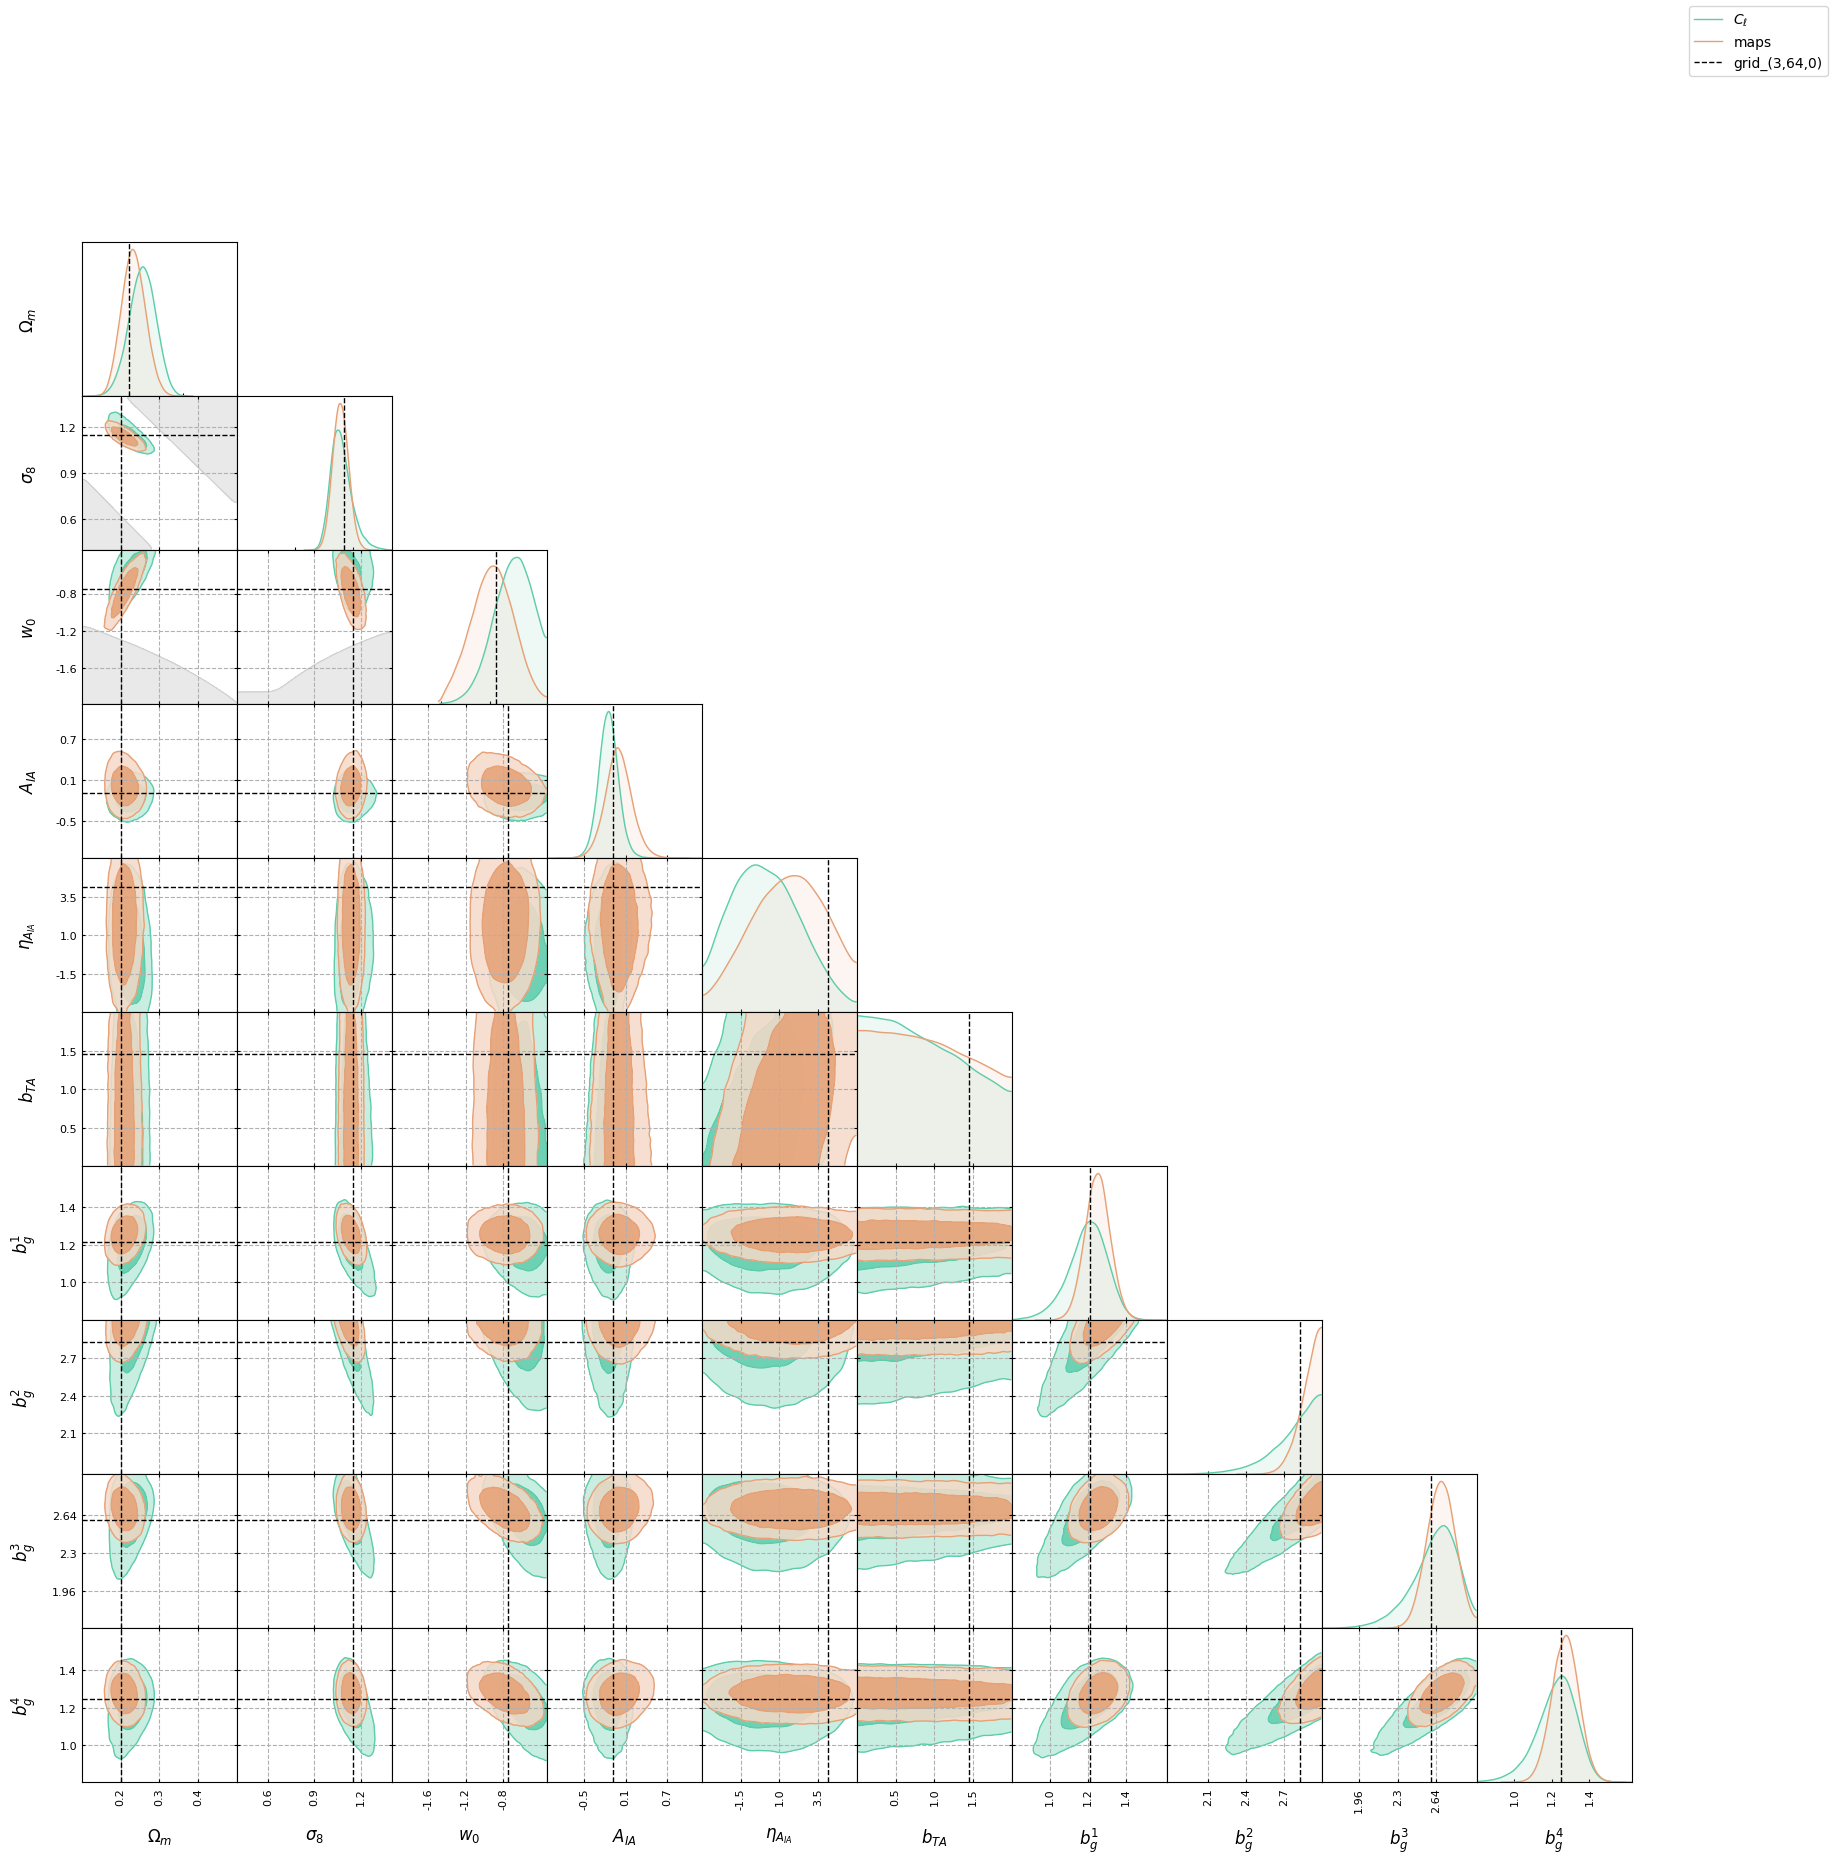

26-06-23 11:23:27     prior.py INF   Generated 3841699 randoms in prior 
26-06-23 11:23:28  plotting.py WAR   Not saving the plot 


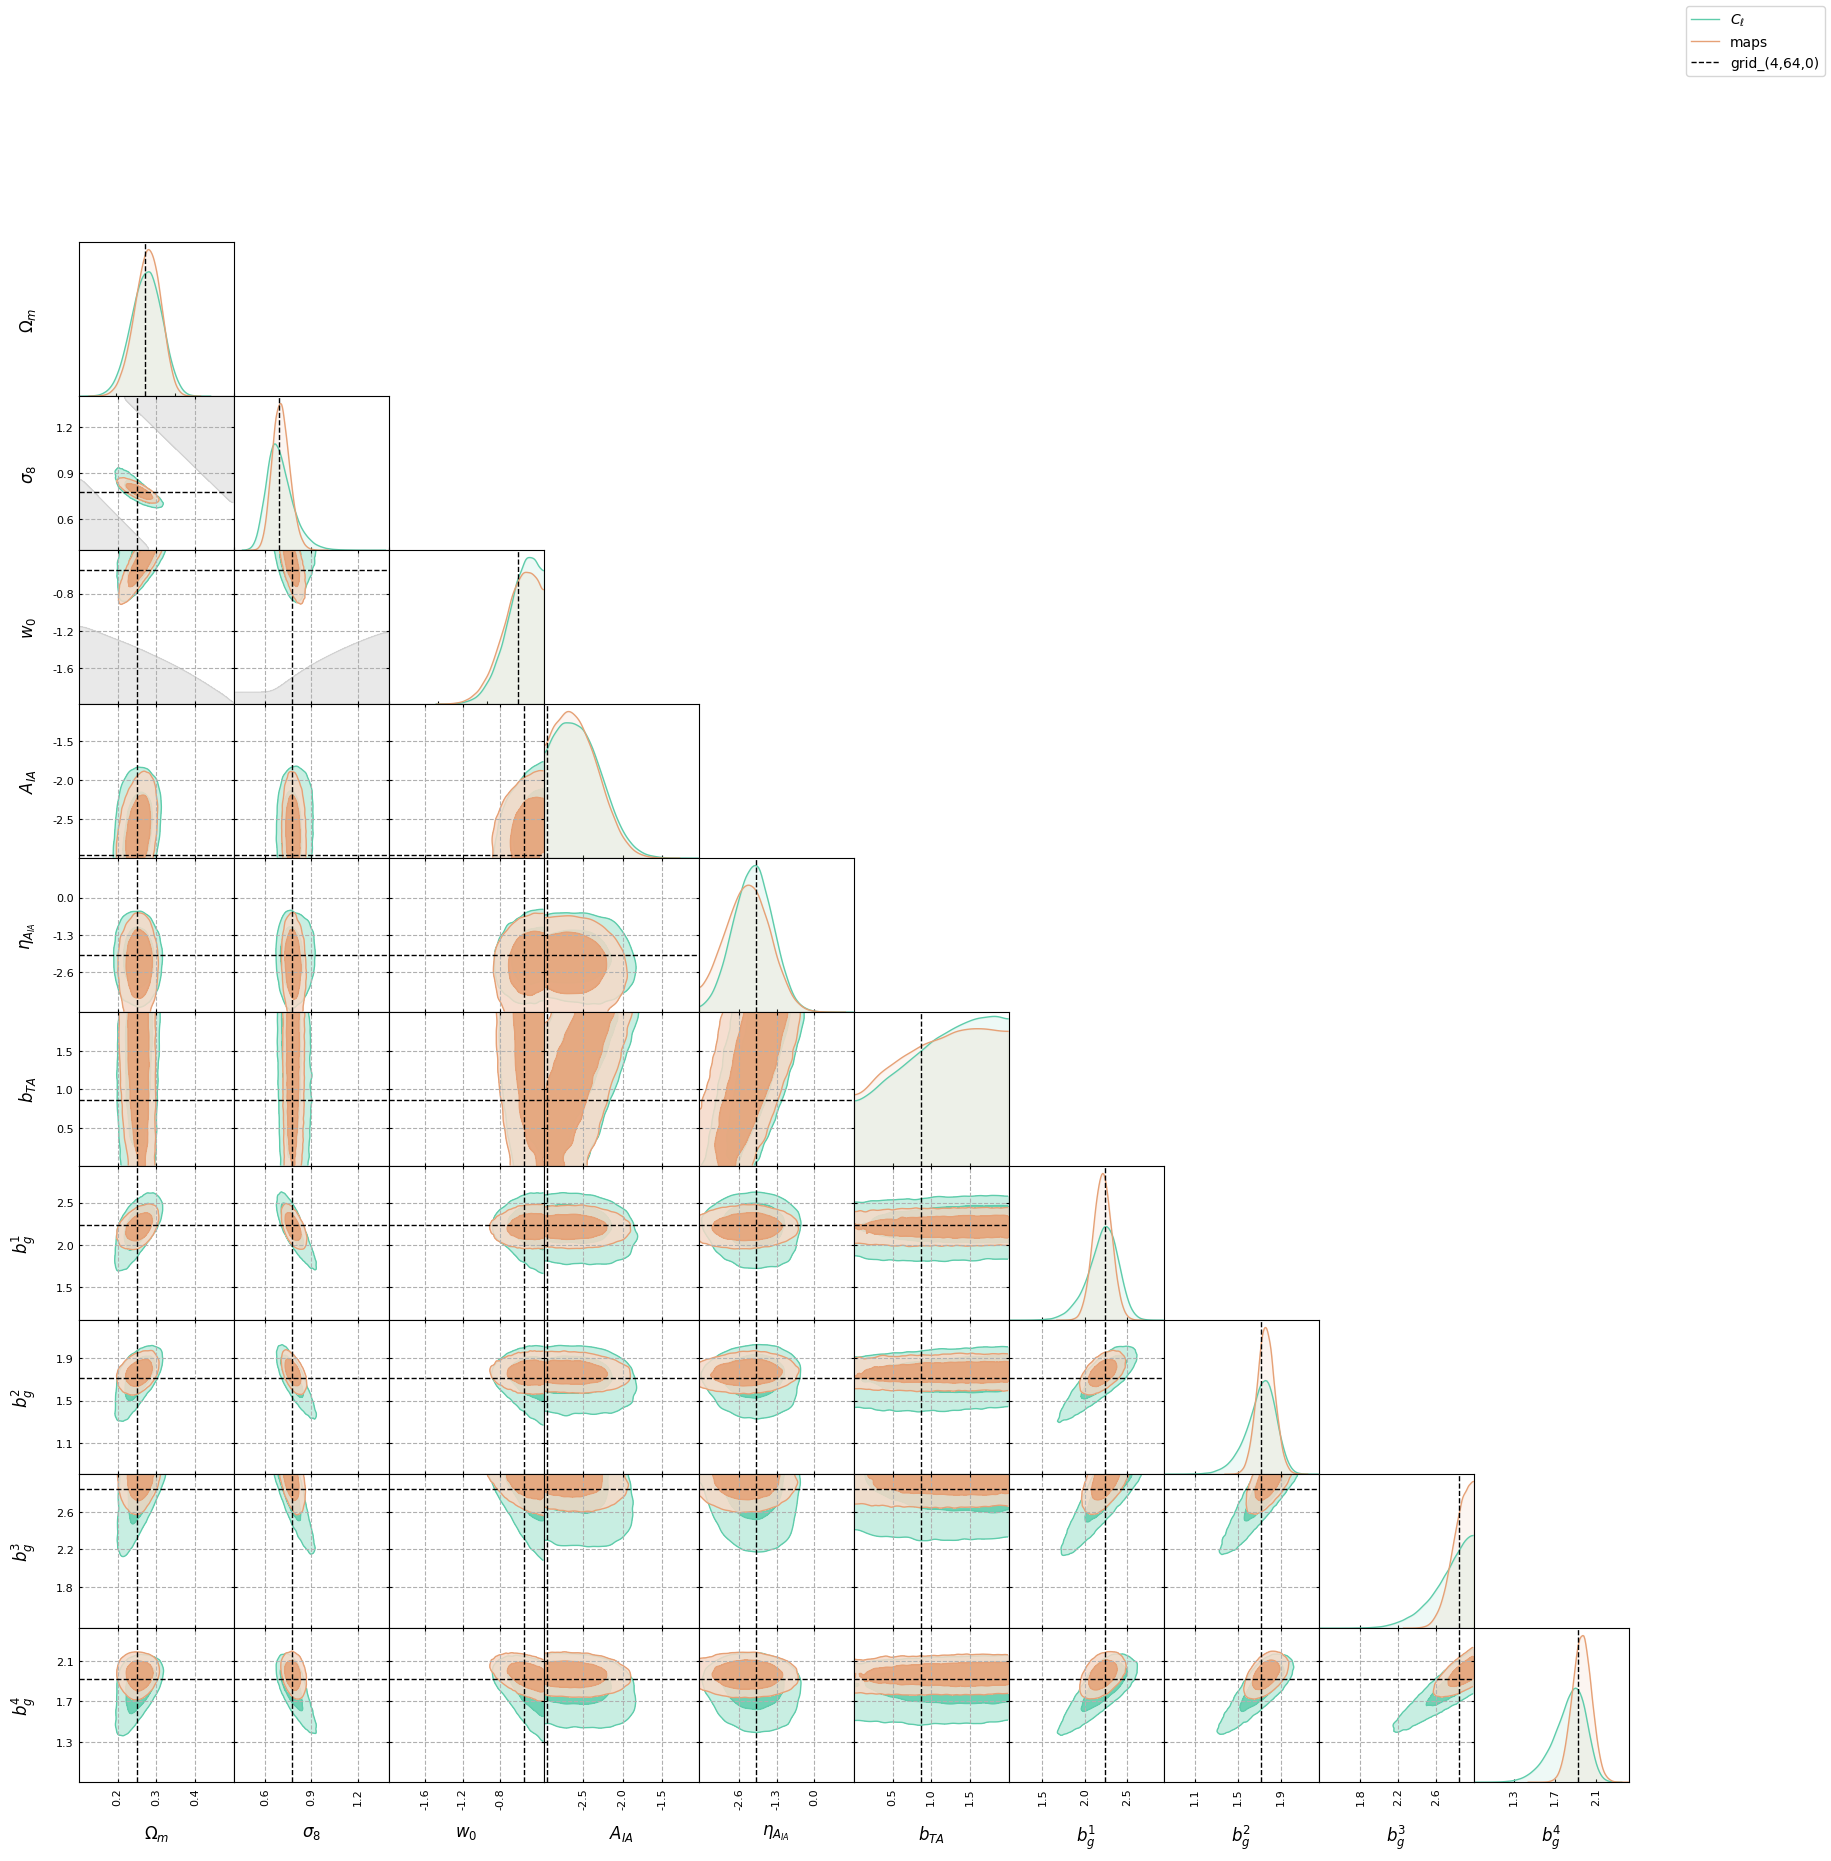

In [36]:
def get_common_obs_labels(dir_a, dir_b):
    def chain_labels(d):
        return {f[len("chain_"):-len(".npy")] for f in os.listdir(d) if f.startswith("chain_") and f.endswith(".npy")}
    return sorted(chain_labels(dir_a) & chain_labels(dir_b))

obs_labels = get_common_obs_labels(flow_dir_maps, flow_dir_cls)

for obs_label in obs_labels:
    if not "des" in obs_label.lower():
        chain_cls  = np.load(os.path.join(flow_dir_cls,  f"chain_{obs_label}.npy"))
        chain_maps = np.load(os.path.join(flow_dir_maps, f"chain_{obs_label}.npy"))
        try:
            obs_cosmo  = dict(zip(params, obs_cosmo_dict[obs_label]))
        except KeyError:
            print(f"obs_label {obs_label} not found in obs_cosmo_dict, skipping...")
            continue

        plotting.plot_chains(
            chains=[chain_cls, chain_maps],
            params=params,
            conf=msfm_conf,
            colors=["#5eccab", "#e6a176"],
            plot_labels=[r"$C_\ell$", "maps"],
            obs_cosmo=obs_cosmo,
            obs_label=obs_label,
            use_S8=False,
            scale_to_prior=False,
            include_prior=True,
            show_legend=True,
        )
        plt.show()